Generate the dataset (uses `src/sample_data.py`)

**Edit `PROJECT_DIR`.**

In [15]:
# !pip install torch

# import torch
# print(torch.cuda.is_available())

# from google.colab import drive
# drive.mount('/content/drive')

# %cd /content/drive/MyDrive/DSNSFcomp/nsf-fmrg-data-challenge

In [16]:
%pip install tensorflow scikit-learn


[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [17]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

In [18]:
# ============================================================
# !important! make the `sample_data.py` file into folder `nsf-fmrg-data-challenge/src` of the original github repo.
# Then, put the direction of `nsf-fmrg-data-challenge` folder on your device below :)
# PROJECT_DIR = Path('/Users/jian/MyProjects/NSF-Future-challenge/nsf-fmrg-data-challenge')

PROJECT_DIR = Path.cwd().parent

print('PROJECT_DIR =', PROJECT_DIR)
# ============================================================

PROJECT_DIR = /Users/qalbemomina/Documents/NSF-Challenge/nsf-fmrg-data-challenge


In [19]:
sys.path.append(str(PROJECT_DIR / 'src'))
from sample_data import SampleGenerator, TRACK_IDS

In [20]:
gen = SampleGenerator(PROJECT_DIR)
print('tracks:', TRACK_IDS, '| grid:', gen.frame_grid()[[0, 1, -1]], 'mm (400 frame centres)')

tracks: (8, 10, 14, 21) | grid: [20.1 20.3 99.9] mm (400 frame centres)


In [21]:
# one sample on demand (given a track and an x)
s = gen.make_sample(8, 60.1)
print({k: (v.shape if hasattr(v, 'shape') else v) for k, v in s.items()})

{'track_id': 8, 'x': 60.1, 'thermal': (5, 400, 400), 'width_mm': 0.666162174582889, 'quality': True}


/Users/qalbemomina/Documents/NSF-Challenge/nsf-fmrg-data-challenge/src/sample_data.py:232: RuntimeWarning: All-NaN slice encountered
  profile_mm = np.nanmedian(z_mm[:, x0:x1], axis=1)
/Users/qalbemomina/Documents/NSF-Challenge/nsf-fmrg-data-challenge/src/sample_data.py:181: RuntimeWarning: All-NaN slice encountered
  profile_mm = np.nanmedian(z_mm[:, x0:x1], axis=1)


## Width labels over the whole grid

`build_labels()` sweeps every frame-centre x for all tracks and returns `width_mm` + a `quality`
flag (False where x is outside a track's height coverage or an edge is clipped). 

Track 8: accepted=308/398 raw_median_um=617.4 raw_std_um=81.9 model_std_um=67.3
Track 10: accepted=187/398 raw_median_um=498.9 raw_std_um=63.5 model_std_um=60.3
Track 14: accepted=196/398 raw_median_um=406.8 raw_std_um=56.4 model_std_um=52.8
Track 21: accepted=11/398 raw_median_um=249.1 raw_std_um=24.9 model_std_um=24.9


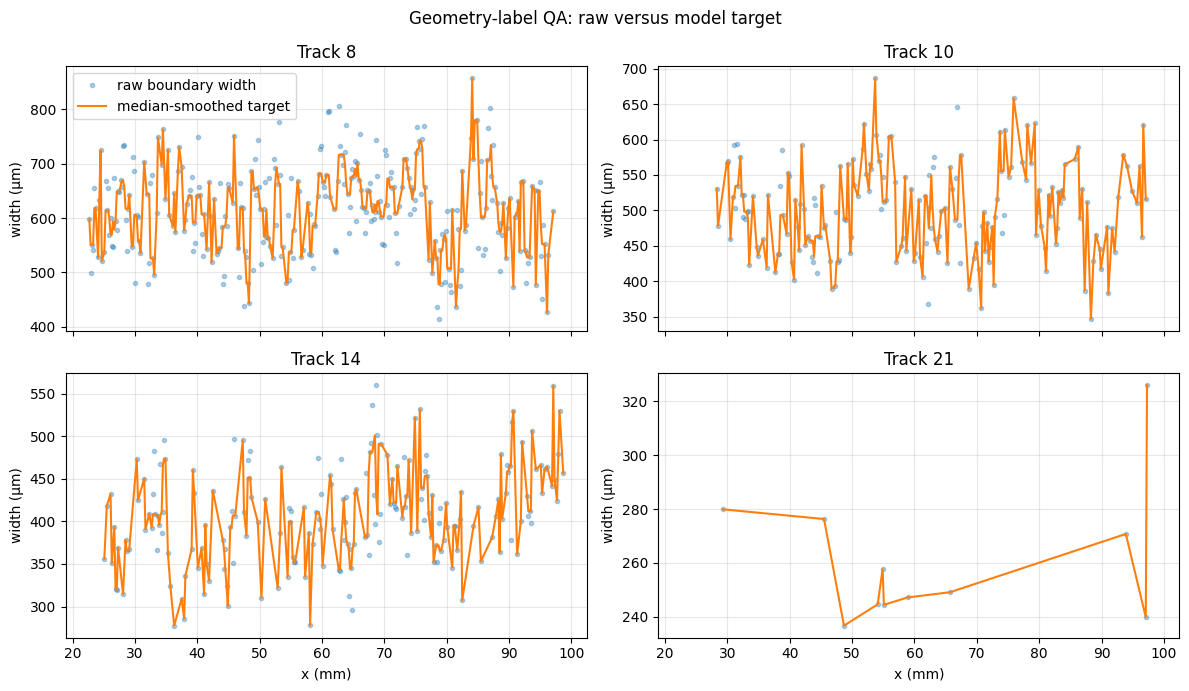

Saved geometry labels to: /Users/qalbemomina/Documents/NSF-Challenge/nsf-fmrg-data-challenge/processed_data/labels_geometry_width.npz


In [22]:
# Build geometry-based labels from actual height values and save them separately from legacy labels.
# Use stable 0.3-mm profiles, a track-calibrated threshold, and final QA.
# model_width_mm is a median-smoothed local descriptor; raw width_mm is preserved.
labels = gen.build_labels(minimum_confidence=0.70, continuity_tolerance_fraction=0.25)
out = PROJECT_DIR / "processed_data" / "labels_geometry_width.npz"
np.savez(out, **labels)
for track_id in TRACK_IDS:
    m = (labels["track_id"] == track_id) & labels["quality"]
    widths = labels["width_mm"][m] * 1000
    model_widths = labels["model_width_mm"][m] * 1000
    print(f"Track {track_id}: accepted={m.sum()}/{(labels['track_id'] == track_id).sum()}",
          f"raw_median_um={np.median(widths) if len(widths) else np.nan:.1f}",
          f"raw_std_um={np.std(widths) if len(widths) else np.nan:.1f}",
          f"model_std_um={np.std(model_widths) if len(model_widths) else np.nan:.1f}")
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, track_id in zip(axes.flat, TRACK_IDS):
    m = (labels["track_id"] == track_id) & labels["quality"]
    ax.plot(labels["x_mm"][m], labels["width_mm"][m] * 1000, ".", alpha=.35, label="raw boundary width")
    ax.plot(labels["x_mm"][m], labels["model_width_mm"][m] * 1000, "-", lw=1.5, label="median-smoothed target")
    ax.set(title=f"Track {track_id}", ylabel="width (µm)"); ax.grid(alpha=.3)
axes[1,0].set_xlabel("x (mm)"); axes[1,1].set_xlabel("x (mm)")
axes[0,0].legend(); fig.suptitle("Geometry-label QA: raw versus model target"); fig.tight_layout(); plt.show()
print("Saved geometry labels to:", out)


In [23]:
## Visualization of width

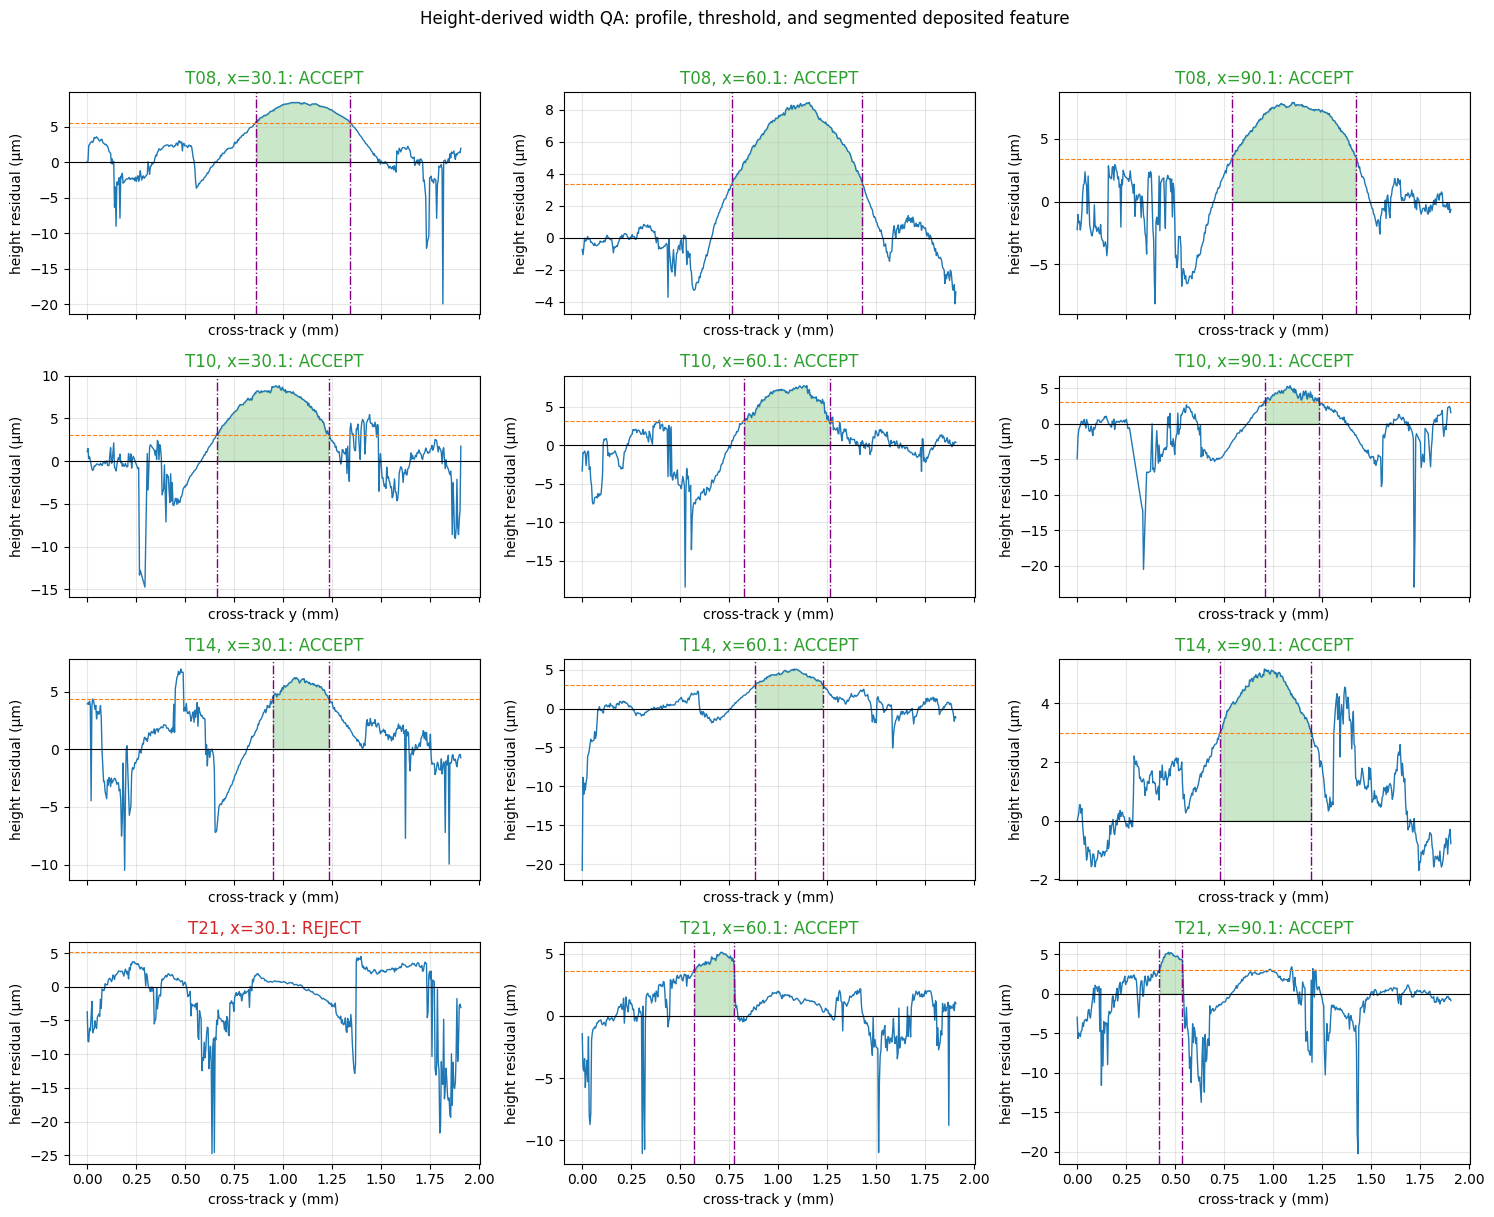

,track_id,x_mm,quality,width_um,left_mm,right_mm,peak_um,threshold_um,confidence,rejection_reason
0,8,30.1,True,481.066695,0.861365,1.342432,8.434466,5.619910,0.750161,accepted
1,8,60.1,True,666.162175,0.764678,1.430841,8.382518,3.385937,0.996806,accepted
2,8,90.1,True,636.190450,0.789186,1.425377,7.793899,3.385937,0.998910,accepted
3,10,30.1,True,569.368331,0.663280,1.232648,8.733388,3.111797,0.940140,accepted
4,10,60.1,True,440.388302,0.826555,1.266943,7.627474,3.163793,0.939339,accepted
5,10,90.1,True,277.828576,0.958011,1.235839,5.081589,3.000000,0.781758,accepted
6,14,30.1,True,286.238045,0.946931,1.233169,6.587314,4.369220,0.753692,accepted
7,14,60.1,True,348.135250,0.882214,1.230349,5.007238,3.000000,0.833900,accepted
8,14,90.1,True,464.945473,0.729832,1.194777,5.108314,3.000000,0.850706,accepted
9,21,30.1,False,NaN,NaN,NaN,3.937193,5.114030,0.000000,feature_too_narrow;feature_touches_y_boundary;...


In [24]:
# Visual QA for actual-height geometry labels. Reject uncertain profiles before ML.
import pandas as pd
qa_x = [30.1, 60.1, 90.1]
fig, axes = plt.subplots(4, 3, figsize=(15, 12), sharex=True)
qa_rows = []
for row, track_id in enumerate(TRACK_IDS):
    for col, x_mm in enumerate(qa_x):
        result = gen.width_at(track_id, x_mm)
        ax = axes[row, col]
        ax.plot(result["y_mm"], result["residual_um"], lw=1, color="tab:blue")
        ax.axhline(0, color="black", lw=.8)
        if result["polarity"]:
            ax.axhline(result["polarity"] * result["threshold_um"], color="tab:orange", ls="--", lw=.8)
        ax.fill_between(result["y_mm"], result["residual_um"], 0, where=result["feature_mask"], alpha=.25, color="tab:green")
        ax.set_title(f"T{track_id:02d}, x={x_mm:.1f}: {'ACCEPT' if result['quality'] else 'REJECT'}",
                     color="tab:green" if result["quality"] else "tab:red")
        if np.isfinite(result["left_boundary_mm"]):
            ax.axvline(result["left_boundary_mm"], color="purple", ls="-.", lw=1)
            ax.axvline(result["right_boundary_mm"], color="purple", ls="-.", lw=1)
        ax.set(xlabel="cross-track y (mm)", ylabel="height residual (µm)")
        ax.grid(alpha=.3)
        qa_rows.append({"track_id":track_id, "x_mm":x_mm, "quality":result["quality"],
                        "width_um":result["width_mm"]*1000, "left_mm":result["left_boundary_mm"],
                        "right_mm":result["right_boundary_mm"], "peak_um":result["peak_height_um"],
                        "threshold_um":result["threshold_um"], "confidence":result["confidence"],
                        "rejection_reason":result["rejection_reason"]})
fig.suptitle("Height-derived width QA: profile, threshold, and segmented deposited feature", y=1.01)
fig.tight_layout(); plt.show()
display(pd.DataFrame(qa_rows))


In [25]:
# Load validated geometry labels and leakage-safe SEM samples for all four tracks.
import pandas as pd
# Final exploratory fit: hyperparameters/epoch count were selected earlier using
# the 8/10 -> 14 experiment.  Track 21 remains completely untouched here.
SEM_TRACKS, TRAIN_TRACKS, TEST_TRACK = [8,10,14,21], [8,10,14], 21
FINAL_TRAIN_EPOCHS = 60  # Set from the separate, whole-track validation experiment.
MIN_ACCEPTED_LABELS_BY_TRACK = {8: 100, 10: 100, 14: 50, 21: 11}
label_path = PROJECT_DIR / "processed_data" / "labels_geometry_width.npz"
labels = np.load(label_path, allow_pickle=False)
required_labels = {"track_id","x_mm","width_mm","model_width_mm","quality","left_boundary_mm","right_boundary_mm","confidence"}
missing = required_labels.difference(labels.files)
if missing: raise KeyError(f"Missing geometry-label arrays: {sorted(missing)}")
for track_id in SEM_TRACKS:
    count = int(((labels["track_id"] == track_id) & labels["quality"]).sum())
    if count < MIN_ACCEPTED_LABELS_BY_TRACK[track_id]:
        raise RuntimeError(f"Track {track_id} has only {count} accepted geometry labels (minimum: {MIN_ACCEPTED_LABELS_BY_TRACK[track_id]}). Review the QA plots and calibrate the height-boundary rule before training.")
label_ids = np.array([f"T{int(t):02d}_X{float(x):05.1f}" for t,x in zip(labels["track_id"],labels["x_mm"])])
label_index = {sample_id:i for i,sample_id in enumerate(label_ids)}
sem_by_track = {}
for track_id in SEM_TRACKS:
    path = PROJECT_DIR / "Samples" / "SEM Samples" / f"SEM_samples_Track_{track_id:02d}.npz"
    with np.load(path, allow_pickle=False) as data:
        required = {"sample_ids","track_ids","x_mm","raw_slices","substrate_only_slices","substrate_masks"}
        if required.difference(data.files): raise KeyError(f"Invalid SEM file: {path}")
        reconstructed = np.where(data["substrate_masks"].astype(bool), data["raw_slices"], 0)
        if not np.array_equal(reconstructed.astype(data["substrate_only_slices"].dtype), data["substrate_only_slices"]):
            raise AssertionError(f"Safe SEM reconstruction failed for Track {track_id}")
        sem_by_track[track_id] = {"ids":data["sample_ids"].astype(str), "x":data["x_mm"].astype(float),
                                  "image":data["substrate_only_slices"].copy(), "mask":data["substrate_masks"].astype(bool).copy()}
print("Geometry-label and safe-SEM inputs loaded.")


Geometry-label and safe-SEM inputs loaded.


In [26]:
# Align geometry labels, safe SEM, and track metadata strictly by sample_id.
parts = []
for track_id in SEM_TRACKS:
    eligible = label_ids[(labels["track_id"] == track_id) & labels["quality"]]
    data = sem_by_track[track_id]; ids = np.intersect1d(data["ids"], eligible)
    if not len(ids): raise ValueError(f"No aligned accepted labels for Track {track_id}")
    lookup = {s:i for i,s in enumerate(data["ids"])}
    si = np.array([lookup[s] for s in ids]); li = np.array([label_index[s] for s in ids])
    parts.append((ids, np.full(len(ids),track_id), data["x"][si], data["image"][si], data["mask"][si], labels["model_width_mm"][li]*1000))
aligned_sample_ids = np.concatenate([p[0] for p in parts]); aligned_track_ids = np.concatenate([p[1] for p in parts])
aligned_x_mm = np.concatenate([p[2] for p in parts]); aligned_sem_images = np.concatenate([p[3] for p in parts])
aligned_sem_masks = np.concatenate([p[4] for p in parts]); aligned_width_um = np.concatenate([p[5] for p in parts]).astype(np.float32)
print(pd.DataFrame({"track":aligned_track_ids}).value_counts().sort_index())


track
8        308
10       187
14       196
21        11
Name: count, dtype: int64


In [27]:
# Load the raw five-frame thermal sequence.  Do not collapse time into summary maps.
k = 2
aligned_thermal = np.stack([gen.thermal_tensor(int(t), float(x), k=k) for t,x in zip(aligned_track_ids, aligned_x_mm)])
print("Raw thermal tensors:", aligned_thermal.shape)


Raw thermal tensors: (702, 5, 400, 400)


In [ ]:
# Final fit: Tracks 8/10/14.  Track 21 is not used for fitting or model selection.
import tensorflow as tf
from sklearn.metrics import mean_absolute_error
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)
sem_input=np.stack([aligned_sem_images.astype(np.float32)/255, aligned_sem_masks.astype(np.float32)],axis=-1)
y_um=aligned_width_um
train_idx=np.flatnonzero(np.isin(aligned_track_ids,TRAIN_TRACKS)); test_idx=np.flatnonzero(aligned_track_ids==TEST_TRACK)
print("Training tracks:", np.unique(aligned_track_ids[train_idx]))
print("Untouched test track:", np.unique(aligned_track_ids[test_idx]))
thermal_scale=max(float(aligned_thermal[train_idx].max()),1.0)
# (sample, time, height, width, channel): full sequence enters the learned encoder.
thermal_sequence=(aligned_thermal.astype(np.float32) / thermal_scale)[...,None]
y_mean=float(y_um[train_idx].mean()); y_std=float(y_um[train_idx].std()); y_z=(y_um-y_mean)/y_std
x_mean=float(aligned_x_mm[train_idx].mean()); x_std=float(aligned_x_mm[train_idx].std()); x_input=((aligned_x_mm-x_mean)/x_std).astype(np.float32)[:,None]
X_sem_train=sem_input[train_idx]; X_th_train=thermal_sequence[train_idx]; X_x_train=x_input[train_idx]
sem_layer=tf.keras.Input(sem_input.shape[1:],name="sem_input"); a=tf.keras.layers.Conv2D(8,3,activation="relu",padding="same")(sem_layer); a=tf.keras.layers.MaxPool2D(2)(a); a=tf.keras.layers.Conv2D(16,3,activation="relu",padding="same")(a); a=tf.keras.layers.GlobalAveragePooling2D()(a)
# Shared spatial CNN per frame, then a GRU over the ordered five-frame sequence.
th_layer=tf.keras.Input(thermal_sequence.shape[1:],name="thermal_sequence")
b=tf.keras.layers.TimeDistributed(tf.keras.layers.Conv2D(8,5,strides=4,activation="relu",padding="same"))(th_layer)
b=tf.keras.layers.TimeDistributed(tf.keras.layers.Conv2D(16,3,strides=2,activation="relu",padding="same"))(b)
b=tf.keras.layers.TimeDistributed(tf.keras.layers.Conv2D(24,3,strides=2,activation="relu",padding="same"))(b)
b=tf.keras.layers.TimeDistributed(tf.keras.layers.GlobalAveragePooling2D())(b)
b=tf.keras.layers.GRU(32,dropout=.10)(b)
x_layer=tf.keras.Input((1,),name="x_input"); c=tf.keras.layers.Dense(8,activation="relu")(x_layer)
z=tf.keras.layers.Concatenate()([a,b,c]); z=tf.keras.layers.Dense(32,activation="relu")(z); z=tf.keras.layers.Dropout(.2)(z); out=tf.keras.layers.Dense(1)(z)
model=tf.keras.Model([sem_layer,th_layer,x_layer],out); model.compile(tf.keras.optimizers.Adam(5e-4),loss=tf.keras.losses.Huber(delta=1.0),metrics=["mae"])
checkpoint=PROJECT_DIR/"processed_data"/"final_t8_t10_t14_sequence.keras"
history=model.fit({"sem_input":X_sem_train,"thermal_sequence":X_th_train,"x_input":X_x_train},y_z[train_idx],epochs=FINAL_TRAIN_EPOCHS,batch_size=8,verbose=2)
model.save(checkpoint)
print(f"Saved final model after {FINAL_TRAIN_EPOCHS} fixed epochs: {checkpoint}")


In [ ]:
print("Thermal sequence used by the model:", thermal_sequence.shape)
print("Train-only normalization scale:", thermal_scale)
print("Sequence mean/std:", float(thermal_sequence.mean()), float(thermal_sequence.std()))


In [ ]:
# No validation is used in the final fit: Track 21 remains untouched until final evaluation.
plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="train loss")
plt.xlabel("epoch"); plt.ylabel("Huber loss (standardized target)"); plt.title("Final 8/10/14 training curve")
plt.grid(alpha=.3); plt.legend(); plt.show()


## Width labels over the whole grid

`build_labels()` sweeps every frame-centre x for all tracks and returns `width_mm` + a `quality`
flag (False where x is outside a track's height coverage or an edge is clipped). 

In [ ]:
# The next cell is the single final evaluation on Track 21.
# Do not use its MAE, predictions, or error table to alter this model.


In [ ]:
# Single final evaluation on the untouched Track 21.
if len(test_idx) < 20: print(f"WARNING: only {len(test_idx)} Track-21 labels; treat this as exploratory, not a final benchmark.")
pred_test=model.predict({"sem_input":sem_input[test_idx],"thermal_sequence":thermal_sequence[test_idx],"x_input":x_input[test_idx]})[:,0]*y_std+y_mean
true_test=y_um[test_idx]; baseline_test=np.full_like(true_test,y_mean)
print("Track-21 MAE model / baseline:",mean_absolute_error(true_test,pred_test),mean_absolute_error(true_test,baseline_test))
result=pd.DataFrame({"sample_id":aligned_sample_ids[test_idx],"x_mm":aligned_x_mm[test_idx],"true_width_um":true_test,"predicted_width_um":pred_test,"error_um":pred_test-true_test}); result["abs_error_um"]=result.error_um.abs(); display(result.sort_values("abs_error_um",ascending=False).head(10))


In [ ]:
# Local geometry width versus position for every track.

fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True, sharey=True)

for ax, track_id in zip(axes.flat, SEM_TRACKS):
    accepted = (
        (labels["track_id"] == track_id)
        & labels["quality"]
        & np.isfinite(labels["width_mm"])
    )

    x = labels["x_mm"][accepted]
    raw_width_um = labels["width_mm"][accepted] * 1000
    model_width_um = labels["model_width_mm"][accepted] * 1000

    order = np.argsort(x)
    x = x[order]
    raw_width_um = raw_width_um[order]
    model_width_um = model_width_um[order]

    ax.scatter(
        x, raw_width_um,
        s=16, alpha=0.40, color="tab:blue",
        label="raw boundary width",
    )
    ax.plot(
        x, model_width_um,
        lw=2, color="black",
        label="median-smoothed training target",
    )

    ax.set_title(
        f"Track {track_id}: n={len(x)}, "
        f"median={np.median(model_width_um):.1f} µm"
    )
    ax.set_xlabel("aligned x (mm)")
    ax.set_ylabel("local width (µm)")
    ax.grid(alpha=0.3)

axes[0, 0].legend(loc="best")
fig.suptitle("Height-derived local width versus scan position", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

In [ ]:
# True local width versus model-predicted local width for all tracks.
pred_all_um = model.predict(
    {
        "sem_input": sem_input,
        "thermal_sequence": thermal_sequence,
        "x_input": x_input,
    },
    verbose=0,
)[:, 0] * y_std + y_mean

fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True, sharey=True)

for ax, track_id in zip(axes.flat, SEM_TRACKS):
    mask = aligned_track_ids == track_id
    order = np.argsort(aligned_x_mm[mask])

    x = aligned_x_mm[mask][order]

    # True target: height-derived, median-smoothed local width.
    true_width_um = aligned_width_um[mask][order]

    # Predicted width: output of the trained CNN + GRU model.
    predicted_width_um = pred_all_um[mask][order]

    ax.plot(
        x, true_width_um,
        color="black", lw=2, label="True local width (height-derived target)",
    )
    ax.plot(
        x, predicted_width_um,
        color="tab:orange", lw=2, alpha=0.9,
        label="Model-predicted local width",
    )

    ax.set_title(f"Track {track_id}")
    ax.set_xlabel("aligned x (mm)")
    ax.set_ylabel("local width (µm)")
    ax.grid(alpha=0.3)

axes[0, 0].legend(loc="best")
fig.suptitle("True versus predicted local width along each track", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()